## SORRM Preliminary Analysis

In [2]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

In [3]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeMonthly' in i:
            new_name = i.replace('timeMonthly_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

In [4]:
# OPEN MESH & DS_OUTPUT FILES, FORMAT

# mesh is the initial condition
mesh_filepath = '/global/cfs/cdirs/e3sm/inputdata/ocn/mpas-o/oQU240/' 
# taken from /pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/Buildconf/mpasoconf/mpaso_in file(which is like a namelist, I guess
mesh_name = 'ocean.QU.240km.151209.nc'
mesh = xr.open_dataset(mesh_filepath + mesh_name)
# set up descriptor for plotting 
# # set up mesh to apply polypcolor
mesh.attrs['is_periodic'] = 'YES'
mesh.attrs['x_period'] = 360
mesh.attrs['y_period'] = 0.0

descriptor = mosaic.Descriptor(mesh,use_latlon=False)
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

#avg_ds_output
filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False, chunks={'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

## ^^ remove the first time, just to get the same size arrays. Not sure what exactly is going on with time with the SORRM runs rn

drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(avg_ds_output.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)


In [5]:
# assign an xtime to mesh (i.e., initial)
new_time = np.array([b'0001-01-01_00:00:00'], dtype='|S64')

mesh['xtime'] = xr.DataArray(new_time, dims=['Time'], coords = {'Time': [0]})
mesh = mesh.drop_vars('Time')

In [6]:
# not really sure why there an open_mfdataset doesn't work for this one...
a = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-02-01_00000.nc')
b = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-03-01_00000.nc')
c = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-04-01_00000.nc')
d = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-05-01_00000.nc')
e = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-06-01_00000.nc')
f = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-07-01_00000.nc')

ss_ds_output = xr.concat([mesh,a, b, c, d, e, f], dim='Time')

In [7]:
sim_res = '240km'
# interpolate / add info needed to make calculations
# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# snapshots at every timestep (dt = ? mins)
# ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
ss_ds_output['salinity'] = ss_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')

In [8]:
for i in avg_ds_output.data_vars:
    if 'Spur' in i:
        print(i)

chiSpurTempBR08
chiSpurSaltBR08


In [9]:
for i in avg_ds_output.data_vars:
    if 'Tendency' in i:
        print(i)

frazilLayerThicknessTendency
frazilTemperatureTendency
temperatureHorizontalAdvectionTendency
salinityHorizontalAdvectionTendency
temperatureVerticalAdvectionTendency
salinityVerticalAdvectionTendency
temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency
temperatureSurfaceFluxTendency
salinitySurfaceFluxTendency
temperatureShortWaveTendency
temperatureNonLocalTendency
salinityNonLocalTendency


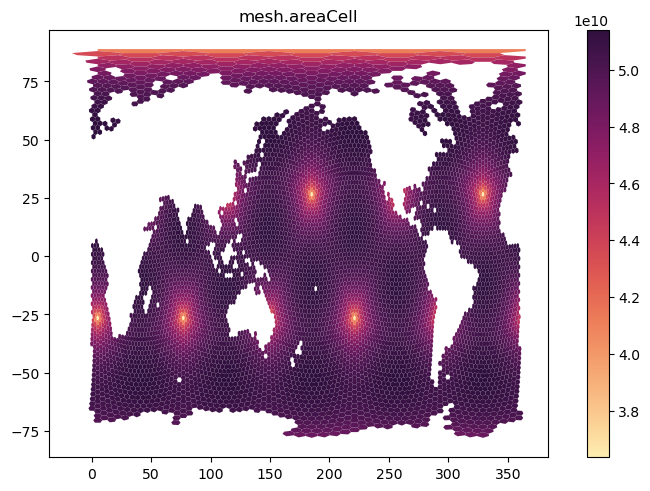

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

a = mosaic.polypcolor(ax, descriptor, mesh.areaCell, cmap='cmo.matter')

ax.set_title('mesh.areaCell')
fig.colorbar(a, ax=ax)

## An attempt to recreate transports calculated on E3SM 30-60km LR transect

From [this github notebook](https://github.com/kailauyeda/MPASO-WMTs/blob/generalize_transects/notebooks/restruc_data_compute_transports.ipynb)

In [11]:
sorrm_filepath = '/global/cfs/cdirs/m5260/kuyeda/20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter/run/'

# this is hist output
# which is snapshots?
# why are there so many more variables than was specifed in streams?
avg_sorrm = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.am.timeSeriesStatsMonthly.0200-01-01.nc')

ss_sorrm = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.0200-02-01_00000.nc')

/tmp/ipykernel_655096/3126566233.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  avg_sorrm = xr.open_dataset(sorrm_filepath + '20260318.v3.SORRME3r3.CRYO2010.bluepulse-beta1-dvd.perlmutter.mpaso.hist.am.timeSeriesStatsMonthly.0200-01-01.nc')


In [12]:
for i in avg_sorrm.data_vars:
    if 'BR' in i:
        print(i)

timeMonthly_avg_chiSpurTracerBR08_chiSpurTempBR08
timeMonthly_avg_chiSpurTracerBR08_chiSpurSaltBR08


In [13]:
for i in avg_sorrm.data_vars:
    if 'Tendency' in i:
        print(i)

timeMonthly_avg_frazilLayerThicknessTendency
timeMonthly_avg_frazilTemperatureTendency
timeMonthly_avg_minGlobalStats_frazilLayerThicknessTendencyMin
timeMonthly_avg_maxGlobalStats_frazilLayerThicknessTendencyMax
timeMonthly_avg_sumGlobalStats_frazilLayerThicknessTendencySum
timeMonthly_avg_rmsGlobalStats_frazilLayerThicknessTendencyRms
timeMonthly_avg_avgGlobalStats_frazilLayerThicknessTendencyAvg
timeMonthly_avg_vertSumMinGlobalStats_frazilLayerThicknessTendencyMinVertSum
timeMonthly_avg_vertSumMaxGlobalStats_frazilLayerThicknessTendencyMaxVertSum
timeMonthly_avg_activeTracerHorizontalAdvectionTendency_temperatureHorizontalAdvectionTendency
timeMonthly_avg_activeTracerHorizontalAdvectionTendency_salinityHorizontalAdvectionTendency
timeMonthly_avg_activeTracerVerticalAdvectionTendency_temperatureVerticalAdvectionTendency
timeMonthly_avg_activeTracerVerticalAdvectionTendency_salinityVerticalAdvectionTendency
timeMonthly_avg_activeTracerVertMixTendency_temperatureVertMixTendency
timeMon

In [14]:
avg_sorrm

<xarray.Dataset> Size: 19GB
Dimensions:                                                                                                                 (
                                                                                                                             nMerHeatTransBinsP1: 181,
                                                                                                                             nCells: 807630,
                                                                                                                             nMocStreamfunctionBinsP1: 181,
                                                                                                                             Time: 1,
                                                                                                                             bnds: 2,
                                                                                                                             nVertLevels: 80,
                                                                                                                             nEdges: 2439246,
                                                                                                                             nVertLevelsP1: 81,
                                                                                                                             nRegions: 5,
                                                                                                                             nOceanRegions: 7,
                                                                                                                             nOceanRegionsTmp: 7)
Coordinates:
  * Time                                                                                                                    (Time) object 8B ...
Dimensions without coordinates: nMerHeatTransBinsP1, nCells,
                                nMocStreamfunctionBinsP1, bnds, nVertLevels,
                                nEdges, nVertLevelsP1, nRegions, nOceanRegions,
                                nOceanRegionsTmp
Data variables: (12/485)
    binBoundaryMerHeatTrans                                                                                                 (nMerHeatTransBinsP1) float32 724B ...
    velocityTidalRMS                                                                                                        (nCells) float32 3MB ...
    binBoundaryMocStreamfunction                                                                                            (nMocStreamfunctionBinsP1) float32 724B ...
    timeMonthly_counter                                                                                                     (Time) int32 4B ...
    xtime_startMonthly                                                                                                      (Time) |S64 64B ...
    xtime_endMonthly                                                                                                        (Time) |S64 64B ...
    ...                                                                                                                      ...
    timeMonthly_avg_numericalMixingTracersSurfaceFluxSubglacialRunoff_passiveTemperatureSquaredSurfaceFluxSubglacialRunoff  (Time, nCells) float32 3MB ...
    timeMonthly_avg_numericalMixingTracersSurfaceFluxSubglacialRunoff_passiveSalinitySquaredSurfaceFluxSubglacialRunoff     (Time, nCells) float32 3MB ...
    timeMonthly_avg_numericalMixingTracersSurfaceFluxRemoved_passiveTemperatureSurfaceFluxRemoved                           (Time, nCells) float32 3MB ...
    timeMonthly_avg_numericalMixingTracersSurfaceFluxRemoved_passiveSalinitySurfaceFluxRemoved                              (Time, nCells) float32 3MB ...
    timeMonthly_avg_numericalMixingTracersSurfaceFluxRemoved_passiveTemperatureSquaredSurfaceFluxRemoved                    (Time, nCells) float32 3MB ...
    timeM

In [15]:
ss_sorrm

<xarray.Dataset> Size: 3GB
Dimensions:            (Time: 1, nCells: 807630, nVertLevels: 80)
Dimensions without coordinates: Time, nCells, nVertLevels
Data variables:
    layerThickness     (Time, nCells, nVertLevels) float64 517MB ...
    refZMid            (nVertLevels) float64 640B ...
    refLayerThickness  (nVertLevels) float64 640B ...
    xtime              (Time) |S64 64B ...
    displacedDensity   (Time, nCells, nVertLevels) float64 517MB ...
    potentialDensity   (Time, nCells, nVertLevels) float64 517MB ...
    density            (Time, nCells, nVertLevels) float64 517MB ...
    refBottomDepth     (nVertLevels) float64 640B ...
    zMid               (Time, nCells, nVertLevels) float64 517MB ...
Attributes: (12/889)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    1a99e17837
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         20260318.v3...
    ...                                                           ...
    config_AM_discreteVarianceDecay_enable:                       YES
    config_AM_discreteVarianceDecay_compute_interval:             dt
    config_AM_discreteVarianceDecay_output_stream:                discreteVar...
    config_AM_discreteVarianceDecay_compute_on_startup:           NO
    config_AM_discreteVarianceDecay_write_on_startup:             NO
    file_id:                                                      9q4byt9znd

In [16]:
sorrm_restart = xr.open_dataset(sorrm_filepath + '20260520.v3.SORRME3r3.CRYO2010.bluepulse-control.chrysalis.mpaso.rst.0200-01-01_00000.nc')
sorrm_restart
# set up descriptor for plotting 
# # set up mesh to apply polypcolor
sorrm_restart.attrs['is_periodic'] = 'YES'
sorrm_restart.attrs['x_period'] = 360
sorrm_restart.attrs['y_period'] = 0.0

sorrm_descriptor = mosaic.Descriptor(sorrm_restart,use_latlon=False)
sorrm_descriptor = mosaic.Descriptor(sorrm_restart, use_latlon=False)

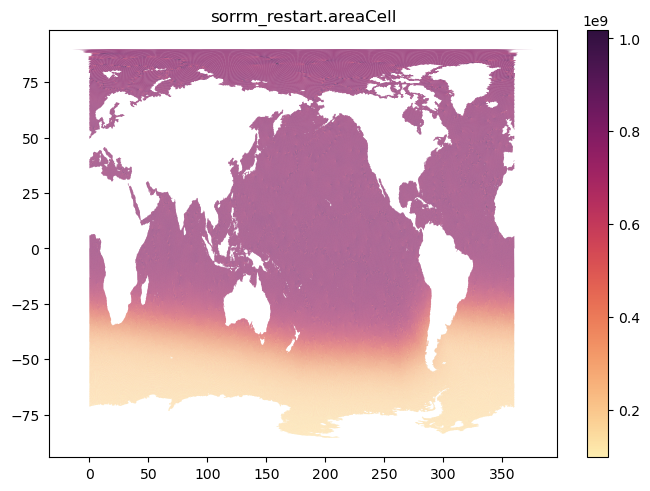

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

a = mosaic.polypcolor(ax, sorrm_descriptor, sorrm_restart.areaCell, cmap='cmo.matter')

ax.set_title('sorrm_restart.areaCell')
fig.colorbar(a, ax=ax)

In [18]:
%load_ext autoreload
%autoreload 2
import mpasregions.sections as mps

In [19]:
mesh = sorrm_restart.assign_coords({
"VertexID": xr.DataArray(sorrm_restart.indexToVertexID, dims=('nVertices',)),
})

ds = mps.add_grid_info_coords(mesh,avg_sorrm)
ds['lonCell'] = ds.lonCell 
ds['lonEdge'] = ds.lonEdge 
ds['lonVertex'] = ds.lonVertex 

In [38]:
# def calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds):
# ---------- INITIATE START VERTEX ----------------
# of these transect cells, select the one that is closest to the desired starting point.
# desired values in deg
# distance_on_unit_sphere(lon1, lat1, lon2, lat 2)
# find the shortest path between the two points
# of all of the points, find the vertex that is closest to the desired start point

target_start_lat = -75
target_start_lon = 280
target_end_lat = -50
target_end_lon = 280

dist_to_start = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_start_lon, target_start_lat)
xr_start_vertex = dist_to_start.argmin()
### print('very first start vertex is ', np.int32(xr_start_vertex))
n_start_vertex = mps.xr_to_n_idx(xr_start_vertex)

start_lon = ds.isel(nVertices = xr_start_vertex).lonVertex * 180/np.pi
start_lat = ds.isel(nVertices = xr_start_vertex).latVertex * 180/np.pi

# repeat to find the vertex that is closest to the desired end point
dist_to_end = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_end_lon, target_end_lat)

# get the vertex closest to the target end lat and lon
xr_end_vertex = dist_to_end.argmin()
### print('xr_end_vertex is ', np.int32(xr_end_vertex))
end_lon = ds.isel(nVertices = xr_end_vertex).lonVertex * 180/np.pi
end_lat = ds.isel(nVertices = xr_end_vertex).latVertex * 180/np.pi

# get an array of the start and end points (this is useful if transects are broken up by land)
xr_start_end_vertices = np.array([xr_start_vertex, xr_end_vertex])

# get distance between target start point and target end point
distance = mps.distance_on_unit_sphere(start_lon, start_lat, target_end_lon, target_end_lat)

# ---------- FIND NEXT VERTEX ----------------
# if start_vertices is None:
#     start_vertices = np.array([])
#     print('starting first segment.')
# else:
#     start_vertices
#     print('starting next segment. already used ', len(start_vertices), ' vertices')
start_vertices = np.array([])
next_vertices = np.array([])

count=0

# while distance.min() > 10: #10000: <-- can't use this. if len(distance) = 0, then distance.min dne, but we can continue to cycle through vertices
while count >=0 :
    count += 1
    
    # get the edges attached to the start vertex
    ### print(np.int32(xr_start_vertex))
    n_edgesOnStartVertex_raw = ds.edgesOnVertex.isel(nVertices = xr_start_vertex) # a zero in this array (in n IDs) means there is a nan in this location
    n_edgesOnStartVertex = n_edgesOnStartVertex_raw[n_edgesOnStartVertex_raw >0]
    # n_edgesOnStartVertex = ds.edgesOnVertex.isel(nVertices = xr_start_vertex)
    xr_edgesOnStartVertex = mps.n_to_xr_idx(n_edgesOnStartVertex)
    ### print('edges attached to start vertex ', np.int32(xr_start_vertex), ' are ', xr_edgesOnStartVertex)
    
    # check that the edges you selected are connected to the start vertex (returns in n indices)
    # ds.verticesOnEdge.isel(nEdges = xr_edgesOnStartVertex[0])
    
    # for each of these edges, find the vertices they are connected to and then remove the start_vertex (we don't want to "travel back" to that vertex)
    n_vertices_nextToStartVertex = np.unique(ds.verticesOnEdge.isel(nEdges = np.int32(xr_edgesOnStartVertex)))
    xr_vertices_nextToStartVertex = mps.n_to_xr_idx(n_vertices_nextToStartVertex)
    # print(xr_vertices_nextToStartVertex)
    ### print('possible vertices to move to are ', xr_vertices_nextToStartVertex)

    # used_vertices = np.union1d(start_vertices, xr_start_vertex)
    used_vertices = np.append(start_vertices, xr_start_vertex)
    ### print('vertices used are' , used_vertices)

    xr_vertices_nextToStartVertex_Use = np.delete(xr_vertices_nextToStartVertex, np.where(np.isin(xr_vertices_nextToStartVertex, used_vertices)))
    ### print('excluding the start vertex, the next vertices we can move to are' , xr_vertices_nextToStartVertex_Use)
    # print(xr_vertices_nextToStartVertex_Use)
    # calculate the distance from these new vertices to the desired end point
        # retrieve the lat and lon of the vertex
    # ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].where(ds.nVertices.isin(xr_vertices_nextToStartVertex_Use))
    ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex_Use)
    ds_vertices_nextLatLon['lonVertex'] = ds_vertices_nextLatLon.lonVertex * 180/np.pi
    ds_vertices_nextLatLon['latVertex'] = ds_vertices_nextLatLon.latVertex * 180/np.pi
    
    # calculate the distance between the next vertices and the target end
    distance = mps.distance_on_unit_sphere(ds_vertices_nextLatLon.lonVertex, ds_vertices_nextLatLon.latVertex, target_end_lon, target_end_lat)

    if len(distance)==0:
        print('stuck in loop. returning to open ocean cell.')
        
        # open ocean means all vertices on the cell are attached to ocean, not land
        transect_vertices = mesh.isel(nVertices = np.int32(used_vertices))
        
        # create nVertex mask that ignores vertices attached to land cells (n_cells =0)
        openOcean_vertexMask = (transect_vertices.cellsOnVertex != 0).all(dim = 'vertexDegree')
        
        # apply the mask to the vertex IDs
        n_openOcean_nVertices = transect_vertices.VertexID.where(openOcean_vertexMask).dropna(dim='nVertices')
        xr_openOcean_nVertices = mps.n_to_xr_idx(n_openOcean_nVertices)
        
        # of these open ocean vertices, which has the largest index in the used_vertices array?
        # this is the most recently visited vertex on an open ocean cell
        last_openOceanVertex = xr_openOcean_nVertices[-1].values

        xr_start_vertex = np.int32(last_openOceanVertex)

        # now that we've returned to the last_openOceanVertex, we need to travel to an unused vertex
        # we repeat the steps above (find edges attached to vertex, find vertices attached to edges, find shortest distance on vertex not already traveled to,
        # travel to that vertex)
        # get the edges attached to the start vertex
        ### print(np.int32(xr_start_vertex))

        
        
        n_edgesOnStartVertex_raw = ds.edgesOnVertex.isel(nVertices = xr_start_vertex) # a zero in this array (in n IDs) means there is a nan in this location
        n_edgesOnStartVertex = n_edgesOnStartVertex_raw[n_edgesOnStartVertex_raw >0]
        # n_edgesOnStartVertex = ds.edgesOnVertex.isel(nVertices = xr_start_vertex)
        xr_edgesOnStartVertex = mps.n_to_xr_idx(n_edgesOnStartVertex)
        ### print('edges attached to start vertex ', np.int32(xr_start_vertex), ' are ', xr_edgesOnStartVertex)
        
        # check that the edges you selected are connected to the start vertex (returns in n indices)
        # ds.verticesOnEdge.isel(nEdges = xr_edgesOnStartVertex[0])
        
        # for each of these edges, find the vertices they are connected to and then remove the start_vertex (we don't want to "travel back" to that vertex)
        n_vertices_nextToStartVertex = np.unique(ds.verticesOnEdge.isel(nEdges = np.int32(xr_edgesOnStartVertex)))
        xr_vertices_nextToStartVertex = mps.n_to_xr_idx(n_vertices_nextToStartVertex)
        # print(xr_vertices_nextToStartVertex)
        ### print('possible vertices to move to are ', xr_vertices_nextToStartVertex)
    
        # used_vertices = np.union1d(start_vertices, xr_start_vertex)
        used_vertices = np.append(start_vertices, xr_start_vertex)
        ### print('vertices used are' , used_vertices)
    
        xr_vertices_nextToStartVertex_Use = np.delete(xr_vertices_nextToStartVertex, np.where(np.isin(xr_vertices_nextToStartVertex, used_vertices)))
        ### print('excluding the start vertex, the next vertices we can move to are' , xr_vertices_nextToStartVertex_Use)
        # print(xr_vertices_nextToStartVertex_Use)
        # calculate the distance from these new vertices to the desired end point
            # retrieve the lat and lon of the vertex
        # ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].where(ds.nVertices.isin(xr_vertices_nextToStartVertex_Use))
        ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex_Use)
        ds_vertices_nextLatLon['lonVertex'] = ds_vertices_nextLatLon.lonVertex * 180/np.pi
        ds_vertices_nextLatLon['latVertex'] = ds_vertices_nextLatLon.latVertex * 180/np.pi
        
        # calculate the distance between the next vertices and the target end
        distance = mps.distance_on_unit_sphere(ds_vertices_nextLatLon.lonVertex, ds_vertices_nextLatLon.latVertex, target_end_lon, target_end_lat)

    chosen_nextVertex_arg = distance.argmin()
    n_chosen_nextVertex = distance.VertexID[chosen_nextVertex_arg]
    xr_chosen_nextVertex = mps.n_to_xr_idx(n_chosen_nextVertex)

    ### print('minimum distance is ', distance.min().values)
    # select the nVertex that is the shortest distance from the end point
    # chosen_nextVertex_arg = distance.argmin()
    # n_chosen_nextVertex = distance.VertexID[chosen_nextVertex_arg]
    # xr_chosen_nextVertex = mps.n_to_xr_idx(n_chosen_nextVertex)
    ### print('the chosen next vertex to move to is ', np.int32(xr_chosen_nextVertex))
    
    # ---------- UPDATE ARRAYS ----------------
    
    # store vertices
    start_vertices = np.append(start_vertices, xr_start_vertex)
    next_vertices = np.append(next_vertices, xr_chosen_nextVertex)

    xr_start_vertex = xr_chosen_nextVertex 

    # break code if the next vertex is the vertex closest to the target end lat and lon
    if xr_chosen_nextVertex == xr_end_vertex:
        print('broken because reached end vertex')
        break

# ---------- FIND EDGES OF TRANSECT ---------------- 
# We want to identify the edges that connect the vertices. The vertices are already ordered consecutively (because the transects are built from an algorithm)
# We will take advantage of this fact using a for loop to extract the edges that are shared between vertices next to each other

# modify next_vertices to also include the start vertex
next_vertices = np.insert(next_vertices, 0, mps.n_to_xr_idx(n_start_vertex))


# next vertices are in xr indices
int_next_vertices = np.int32(next_vertices)
n_transect_edges = np.array([])

for i in range(0,len(int_next_vertices)-1):
    edgesOnVertex0 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i]).values
    edgesOnVertex1 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i+1]).values
    shared_edge = np.intersect1d(edgesOnVertex0, edgesOnVertex1)
    n_transect_edges = np.append(n_transect_edges, shared_edge)

xr_transect_edges = mps.n_to_xr_idx(n_transect_edges)

    
# return xr_transect_edges, next_vertices

stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in loop. returning to open ocean cell.
stuck in l

KeyboardInterrupt: 

In [41]:
xr_vertices_nextToStartVertex

array([3369, 3370, 3371, 3558], dtype=int32)

In [25]:
lats = np.array([-75,-50,-50,-75])
lons = np.array([280, 280, 300, 300])
test_edges, test_verts = mps.calculate_transects_multiple_pts(lons, lats, ds)

ValueError: numpy.nanargmin raises on a.size==0 and axis=None; So Bottleneck too.

(240.0, 360.0)

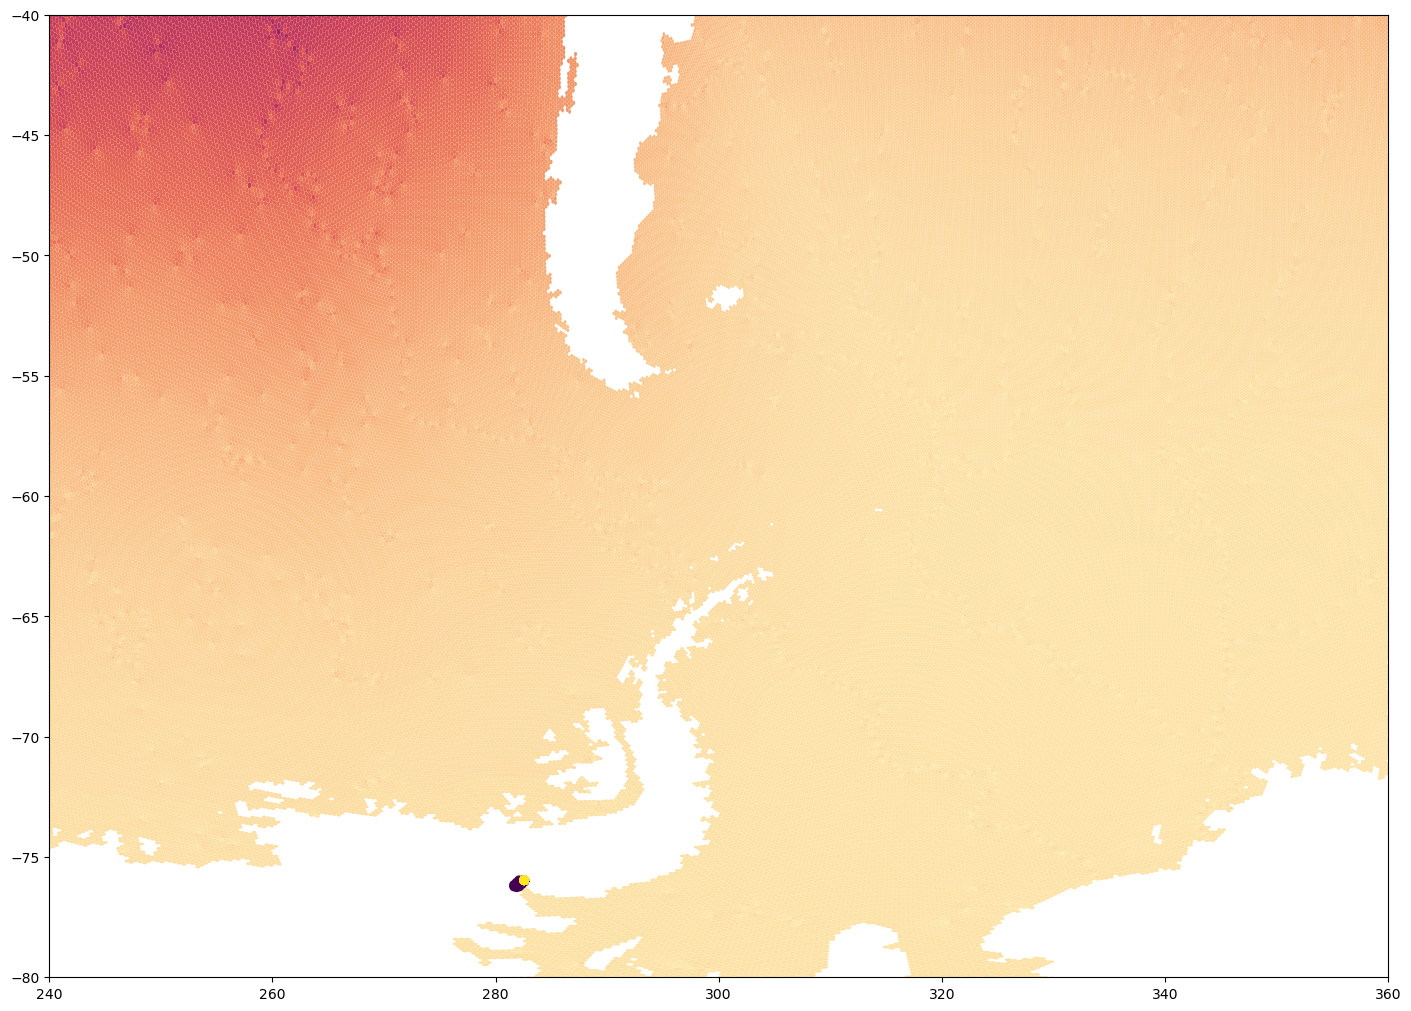

In [33]:
# plot using vertex lats and lons (removed vertices on cells not in the mask)
vertex_lons = ds.lonVertex.isel(nVertices = np.int32(next_vertices)) * 180 / np.pi
vertex_lats = ds.latVertex.isel(nVertices = np.int32(next_vertices)) * 180 / np.pi

# plot the vertices after removing where there are duplicates. 

# plot this masked region
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(14,10))

# the colorbar shows the index of the lons and lats for each vertex 
# (since it is a gradient --> the vertex lats and lons are in order)
a = mosaic.polypcolor(ax, sorrm_descriptor, sorrm_restart.areaCell, cmap='cmo.matter')
ax.scatter(vertex_lons,vertex_lats,c=np.arange(0,len(vertex_lons)),label='2. mask_verts')


ax.set_ylim(-80,-40)
ax.set_xlim(240,360)


In [57]:
# create mask for region for transect
path = './'
filename = 'SORRM_Drake_Passage_transect_test0'
geojson_file_name = 'Southern Ocean region encomapssing Drake passage from transect algorithm'
tags = "Southern_Ocean"
author = "Kaila Uyeda"

lats = np.array([-75,-50,-50,-75])
lons = np.array([250, 250, 350, 350])

target_coords = np.linspace(1022,1029,100)

alg_edges, alg_vertices, mask, dss_transect_edges_vIM, transport_transformed_cons = mps.transports_in_density_space_all_functions(ds,lats,lons,path,filename,
                                                                                                                          geojson_file_name,tags,author, target_coords,'alg')
    

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because no more vertices to travel to
Creating geojson file from vertices identified with transect algorithm
geojson file created
Creating netcdf mask file from geojson file (vertices identified from transect algorithm)


GEOSException: TopologyException: side location conflict at 281.00585501773276 -79.986671115136033. This can occur if the input geometry is invalid.

In [58]:
alg_edges

NameError: name 'alg_edges' is not defined

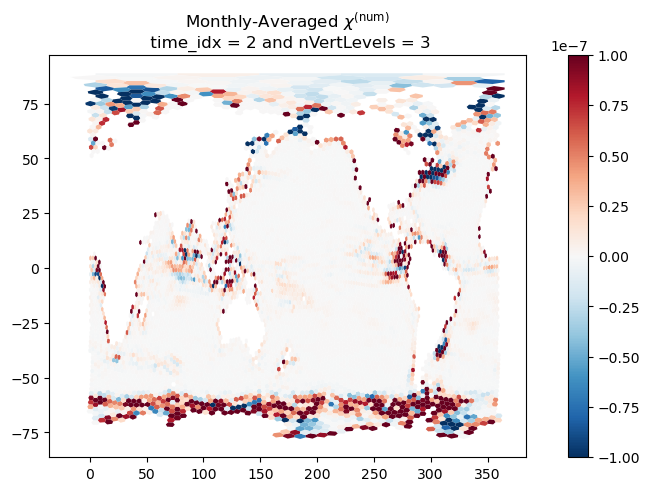

In [77]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

time_idx = 2
nVertLevels_idx = 3
vmax_val = 1e-7
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor, avg_ds_output.chiSpurSaltBR08.isel(Time=time_idx, nVertLevels =3), vmin = vmin_val, vmax = vmax_val, cmap='RdBu_r')

ax.set_title(r'Monthly-Averaged $\chi^{\text{(num)}}$' + '\n time_idx = ' + f'{time_idx} and nVertLevels = {nVertLevels_idx}')
fig.colorbar(a, ax=ax)

In [78]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # F_variable = 'salinityVertMixTendency'
    # target_coord_spacing = 1
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
                                                                          'Z',
                                                                          padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy, 'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds

In [79]:
## CHUNKING ATTEMPT

#avg_ds_output
filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False)
# avg_ds_output = avg_ds_output.chunk({'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(avg_ds_output.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

sim_res = '240km'
# interpolate / add info needed to make calculations
# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# write function to calculate G_F_phy
# rho_0 = 1026
# F_variable = 'salinityVertMixTendency'
# target_coord_spacing = 1
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # target_coord_spacing = 0.5
    # ds_output = avg_ds_output
    # F_variable = 'salinityVertMixTendency' 
    time_chunksize = len(ds_output.Time)
    nCells_chunksize = len(ds_output.nCells)
    
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    salinity_P1_chunksize = len(target_coords_P1)
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    # ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
    #                                                                       'Z',
    #                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk(
                                                                        {'Time' : time_chunksize, 'nCells' : nCells_chunksize, 'salinity_P1' : salinity_P1_chunksize}),
                                                                         'Z',
                                                                         padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : salinity_P1_chunksize-2 , 'Time' : time_chunksize, 'nCells' : nCells_chunksize}), 
                                                                'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds


In [80]:
# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')

    time_chunksize = len(ds_output.Time)
    nCells_chunksize = len(ds_output.nCells)
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    salinity_P1_chunksize = len(target_coords_P1)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'].chunk(
                                                     {'Time' : time_chunksize, 'nCells' : nCells_chunksize, 'salinity_P1' : salinity_P1_chunksize}),
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [81]:
def calculate_dt(avg_ds_output):

    time_format = '%Y-%m-%d_%H:%M:%S'
    t0 = datetime.strptime(avg_ds_output.xtime.values[0].item().decode(), time_format)
    t1 = datetime.strptime(avg_ds_output.xtime.values[1].item().decode(), time_format)
    
    dt = (t1 - t0).total_seconds()
    return dt

In [82]:
def calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
    # target_coord_spacing = 1
    lower_bound = avg_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = avg_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    
    mass = rho_0 * ss_ds_output.layerThickness * mesh.areaCell
    
    ss_ds_grid = Grid(ss_ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                      padding = 'extend',
                      autoparse_metadata = False)
    
    mass_transform = ss_ds_grid.transform(mass, 
                                'Z',
                                target_coords_P1,
                                method = 'conservative',
                                target_data = ss_ds_output.salinity_P1).fillna(0)
    
    mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})
    
    mass_transform_ds = mass_transform.to_dataset(name='mass_transform')
    mass_transform_ds['salinity_P1'] = target_coords_P1
    mass_transform_ds = mass_transform_ds.set_coords({'salinity_P1' : target_coords_P1})
    
    salinity_grid = Grid(mass_transform_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    mass_vint_salinity_P1 = salinity_grid.cumsum(mass_transform_ds.mass_transform, 
                                                 'Z',
                                                 to = 'outer',
                                                 reverse = True)
    mass_vint_salinity = salinity_grid.interp(mass_vint_salinity_P1, 
                                              'Z',
                                              padding = 'extend').transpose('Time','nCells','salinity')
    
    dM = mass_vint_salinity.diff('Time') 
    dt = calculate_dt(ss_ds_output)
    
    dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')
    
    return mass, mass_transform, dM_dt

In [83]:
def calculate_G_F_num(dM_dt, G_F_phy_ds):
    G_F_num = (dM_dt.dM_dt - G_F_phy_ds.G_F_phy_center).transpose('salinity','nCells','Time')
    G_F_num_ds = G_F_num.to_dataset(name = 'G_F_num')
    return G_F_num_ds

In [84]:
# wrapper function to perform all calculations
def calculate_budget(rho_0, mesh, ds_output, target_coord_spacing = 1):
    print('Calculating G_F_phy')
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

    print('Calculating dM/dt')
    mass, mass_transform, dM_dt_ds = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
    
    print('Calculating G_F_num')
    G_F_num_ds = calculate_G_F_num(dM_dt_ds, G_F_phy_ds)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    budget_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              dM_dt_ds,
                              G_F_num_ds,
                              avg_ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds
 

In [85]:
# ## WORKING FUNCTION
# # write function to calculate G_F_phy
# # rho_0 = 1026
# # F_variable = 'salinityVertMixTendency'
# # target_coord_spacing = 1
# rho_0 = 1026
# target_coord_spacing = 0.5
# ds_output = avg_ds_output
# F_variable = 'salinityVertMixTendency' 

# # calculate the integrand
# dV = (mesh.areaCell * ds_output.layerThickness)
# tendency = rho_0 * ds_output[F_variable] * dV

# # Remap to salinity coordinates
# # to conservatively remap with xgcm:
# # >- datavariables must sit on cell centers
# # >- must supply cell edges to calculate remap
# # >- datavariable will be transformed onto cell center
# # So we must
# # >- ensure datavariable sits on salinity to begin with
# # >- supply outer (P1) coordinate for the transformation
# # >- transform such that the datavariable sits on salinity and not nVertLevels

# # set up salinity data to be target coords
# # not for this set up, but good practice in case there's topography
# # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
# # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# # calculate target salinity coordinates (salinity_P1)
# # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
# grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
#                         padding = 'extend', 
#                         autoparse_metadata=False)

# ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')

# # +2 to ensure that the upper and lower bins have a Gphy = 0
# # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
# # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2

# lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
# upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

# target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
# dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# # we know that target_coords_P1 is evenly spaced, so taking an average is easy
# target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
# salinity_trimmed = target_coords[1:-1]

# # transform integrand onto salinity coordinates
# da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
#                                                        'Z', # axis of transformation
#                                                        target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
#                                                        method = 'conservative', # method
#                                                        target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

# # rename (should be on salinity coords)
# ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

# ds_F_tendency_transformed['salinity_P1'] = target_coords_P1

# salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
#                         padding = 'extend',
#                         autoparse_metadata = False)

# # reverse cumsum (now sits on salinity_P1)
# da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
#                                                             'Z',
#                                                             to = 'outer',
#                                                             reverse=True)

# # convert from dataarray to dataset
# ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
# ds_F_volume_int_tendency_transformed['salinity'] = target_coords

# # remap back onto salinity coordinates
# # ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
# #                                                                       'Z',
# #                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)

# ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk({'Time' : 6, 'nCells' : 7153, 'salinity_P1' : 65}),
#                                                                      'Z',
#                                                                      padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')

# # calculate the derivative of the integrand
# # create array
# G_F_phy = []

# # taking the difference remaps from salinity coords to salinity_P1 coords
# for i in range(0,len(target_coords)-1):
#     d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
#                                                                      'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
#     d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
#     G_F_phy.append(d_tracerMassFlux_dlambda)

# # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
# salinity_P1_trimmed = target_coords_P1[1:-1]

# G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
# G_F_phy_ds['salinity'] = target_coords[1:-1]

# # remap back onto salinity coordinates
# # make a new grid that has the trimmed cordinates
# salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
#                            padding = 'extend',
#                            autoparse_metadata= False)

# G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : 63, 'Time' : 6, 'nCells' : 7153}), 'Z', padding='extend')

# G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])


In [ ]:
ss_ds_output.xtime.values[0]#.item().decode()

In [ ]:
ss_ds_output.xtime

In [87]:
rho_0 = 1026
target_coord_spacing = 0.5 # 1 # 0.25

mass, mass_transform, dM_dt = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_F_phy
Calculating G_chi_phy
Calculating G_chi_num
Calculating dM/dt
Calculating G_F_num


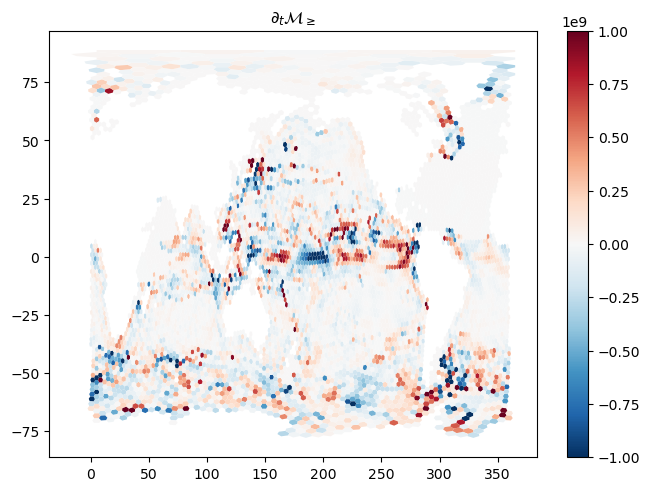

In [94]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(dM_dt.dM_dt).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\partial_t \mathcal{M}_\geq$')
fig.colorbar(a, ax=ax)

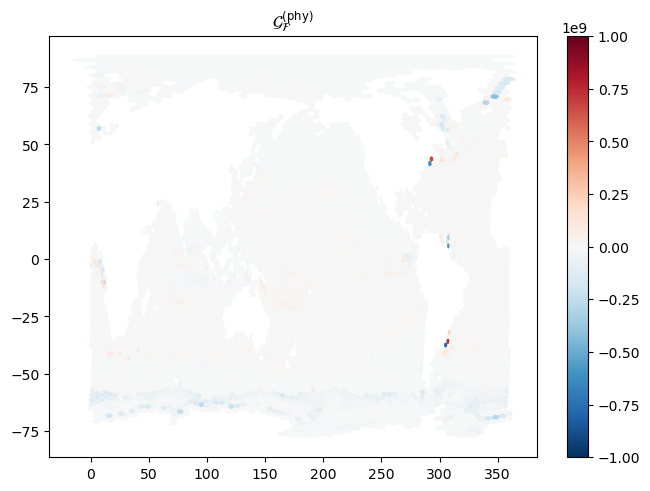

In [93]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_F_phy_center).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
fig.colorbar(a, ax=ax)

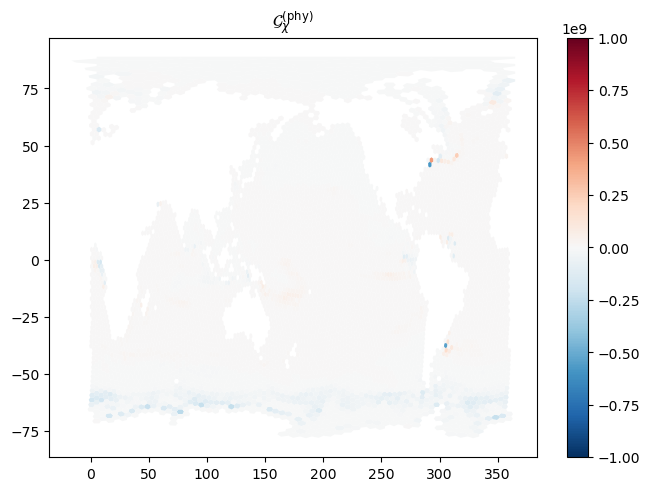

In [95]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_chi_phy).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\chi^{\text{(phy)}}$')
fig.colorbar(a, ax=ax)

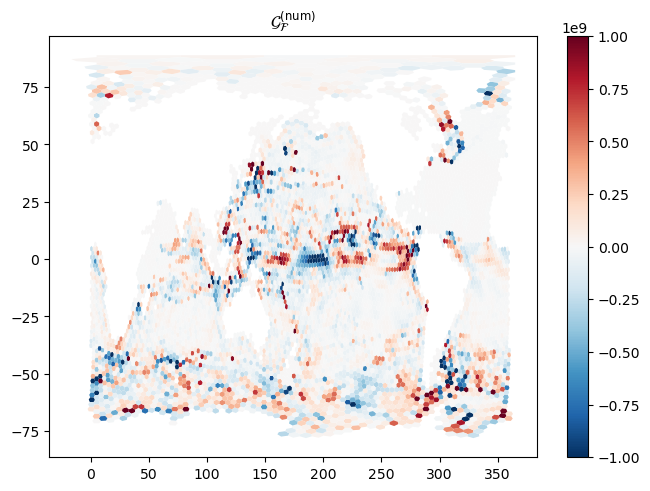

In [96]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_F_num).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(num)}}$')
fig.colorbar(a, ax=ax)

In [99]:
budget_ds.salinity.isel(salinity = 55)

<xarray.DataArray 'salinity' ()> Size: 8B
array(34.44165516)
Coordinates:
    salinity  float64 8B 34.44

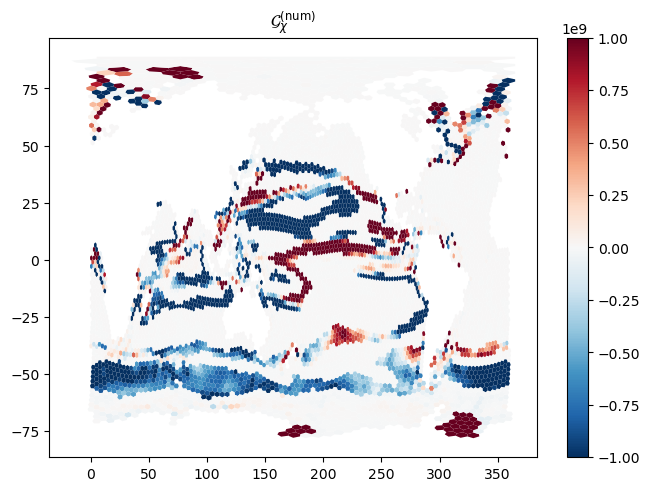

In [97]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(budget_ds.G_chi_num).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e9, vmax = 1e9)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\chi^{\text{(num)}}$')
fig.colorbar(a, ax=ax)